In [696]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import mannwhitneyu as mwu
import ezodf

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from decimal import Decimal
from statannot import add_stat_annotation as asa
from tqdm import tqdm 
import io
from Bio.SeqUtils import molecular_weight as calculate_molecular_weight


from scipy.stats import normaltest
from scipy.stats import pearsonr

import sys
sys.path.insert(1, '../../scripts/') # comment out in python script
from utils.load_environmental_variables import *

In [2]:
def read_ods(filename, sheet_no=0, header=0):
    tab = ezodf.opendoc(filename=filename).sheets[sheet_no]
    return pd.DataFrame({col[header].value:[x.value for x in col[header+1:]]
                         for col in tab.columns()})

In [52]:
# load data

# Alon data
df = read_ods(local_data_path + 'raw/humanRates.ods', sheet_no = 1)
df.rename(columns = {df.columns[0]: 'ENSG_ID', 'bp': 'log10_bp', 'bm': 'log10_bm', 
                    'p': 'log10_p', 'm': 'log10_m', 'RNA.RPKM': 'log10_RNA.RPKM', 
                    'RPF.RPKM': 'log10_RPF.RPKM'}, inplace = True)

for col in ['log10_RNA.RPKM', 'log10_bp', 'log10_bm', 'log10_p', 'log10_m', 'log10_RPF.RPKM']:
    df[col.split('log10_')[1]] = 10**df[col]

df['PTR'] = df.p/df.m
df['corrected_bp'] = df.bp/df.PTR
df['corrected_p'] = df.m*df.PTR
df['log10_corrected_p'] = np.log10(df.corrected_p)

# Uhlen data
rtp_uhlen = pd.read_excel(local_data_path + 'raw/RTP_Uhlen.xlsx', header = 2).drop(index = [0]).reset_index(drop = True)
ids = pd.read_csv(local_data_path + 'raw/MANE.GRCh38.v0.9.summary.txt', sep = '\t')
id_map = dict(zip(ids.symbol.tolist(), ids.Ensembl_Gene.apply(lambda x: x.split('.')[0]).tolist()))
rtp_uhlen['ENSG_ID'] = rtp_uhlen['Gene \ Sample'].map(id_map)

In [87]:
# kinetic parameters
import math
N_p = 7.5*(10**9)
N_m = 225000 #[mrna molecules/cell]

alpha_p = 0.05

constant = (N_p*alpha_p*df['RNA.RPKM'].sum())/(N_m*df['RPF.RPKM'].sum())

In [101]:
constant = (N_p*alpha_p*df.m.sum())/(N_m*df.p.sum())

In [109]:
((N_m/df['RNA.RPKM'].sum())*df['RNA.RPKM']).sum()

225000.0

In [114]:
(N_m*alpha_p)/N_p

1.5e-06

In [116]:
alpha_p

0.05

In [111]:
N_m

225000

In [94]:
constant

1666.6666666666667

In [98]:
df.bp/df.PTR

0       0.051507
1       0.051507
2       0.051507
3       0.051507
4       0.051507
          ...   
8444    0.051507
8445    0.051507
8446    0.051507
8447    0.051507
8448    0.051507
Length: 8449, dtype: float64

In [96]:
df['RNA.RPKM']/df['RPF.RPKM']

0       0.320284
1       1.719163
2       1.417950
3       0.885005
4       0.926713
          ...   
8444    2.759399
8445    0.580073
8446    1.409857
8447    0.345281
8448    0.004516
Length: 8449, dtype: float64

In [86]:
df.m/df['RNA.RPKM']

0       0.560646
1       0.560646
2       0.560646
3       0.560646
4       0.560646
          ...   
8444    0.560646
8445    0.560646
8446    0.560646
8447    0.560646
8448    0.560646
Length: 8449, dtype: float64

In [80]:
N_p/df['RPF.RPKM'].sum()

8535.492752853965

In [81]:
N_m/df['RNA.RPKM'].sum()

0.5709306013359192

/Users/joycebaghdassarian/opt/anaconda3/envs/human_me/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Alon HeLa v.s. Uhlen Median: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=2.397e-01 U_stat=2.596e+05
Uhlen Median v.s. Uhlen HeLa: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.000e+00 U_stat=1.394e+03
Alon HeLa v.s. Uhlen HeLa: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.511e-01 U_stat=2.542e+05


/Users/joycebaghdassarian/opt/anaconda3/envs/human_me/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


''

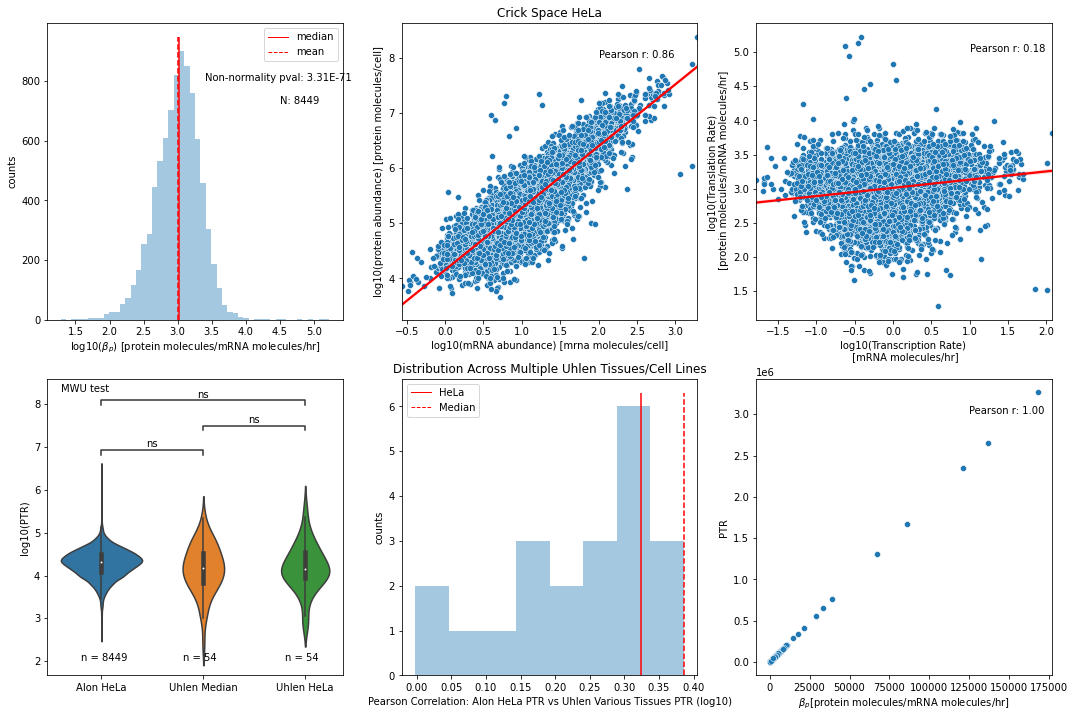

In [4]:
fig, ax = plt.subplots(ncols = 3, nrows = 2, figsize = (18,12))

sns.distplot(df.log10_bp, ax = ax[0,0], kde = False)
ylim = ax[0,0].get_ylim()
ax[0,0].vlines(x = df.log10_bp.median(axis = 0), ymin = ylim[0], ymax = ylim[1], color = 'red')
ax[0,0].vlines(x = df.log10_bp.mean(axis = 0), ymin = ylim[0], ymax = ylim[1], color = 'red', linestyle = '--')
colors = {'solid': 'red', '--': 'red'}
lines = [Line2D([0], [0], color=c, linewidth=1, linestyle=l) for l,c in colors.items()]
labels = ['median', 'mean']
ax[0,0].legend(lines, labels)
ax[0,0].annotate('N: {}'.format(df.bp.dropna().shape[0]), xy = (4.5, 725))
ax[0,0].annotate('Non-normality pval: {:.2E}'.format(Decimal(normaltest(df.log10_bp).pvalue)), xy = (3.4, 800))
ax[0,0].set(xlabel = 'log10(' + r'$\beta_p$' + ') [protein molecules/mRNA molecules/hr]', ylabel = 'counts')

sns.scatterplot(x = 'log10_m', y = 'log10_p', data = df, ax = ax[0,1])
sns.regplot(x = 'log10_m', y = 'log10_p', data = df, ax = ax[0,1], color = 'red', scatter = False)
ax[0,1].annotate('Pearson r: {:.2f}'.format(pearsonr(df.log10_m, df.log10_p)[0]), xy = (2, 8))
ax[0,1].set(xlabel = 'log10(mRNA abundance) [mrna molecules/cell]', 
            ylabel = 'log10(protein abundance) [protein molecules/cell]', 
            title = 'Crick Space HeLa')

sns.scatterplot(x = 'log10_bm', y = 'log10_bp', data = df, ax = ax[0,2])
sns.regplot(x = 'log10_bm', y = 'log10_bp', data = df, ax = ax[0,2], color = 'red', scatter = False)
ax[0,2].set(ylabel = 'log10(Translation Rate) \n [protein molecules/mRNA molecules/hr]', 
            xlabel = 'log10(Transcription Rate) \n [mRNA molecules/hr]')
ax[0,2].annotate('Pearson r: {:.2f}'.format(pearsonr(df.log10_bm, df.log10_bp)[0]), xy = (1, 5))


viz_df = pd.DataFrame(data = {'log10_PTR': np.log10(df.PTR).tolist() + np.log10(rtp_uhlen.Median).tolist() + np.log10(rtp_uhlen.HeLa).tolist(), 
                              'Source': ['Alon HeLa']*df.shape[0] + ['Uhlen Median']*rtp_uhlen.shape[0] + ['Uhlen HeLa']*rtp_uhlen.shape[0]})
sns.violinplot(y = 'log10_PTR', x = 'Source', data = viz_df, ax = ax[1,0])
# sns.distplot(np.log10(rtp_uhlen.Median), kde=True, ax = ax[1,0], color = 'orange')
ax[1,0].set(ylabel = 'log10(PTR)', xlabel = '')

tests = asa(ax[1,0], data=viz_df, y = 'log10_PTR', x = 'Source',
                                   box_pairs=[("Alon HeLa", "Uhlen Median"), ("Uhlen Median", "Uhlen HeLa"), ("Alon HeLa", "Uhlen HeLa")],
                                   test='Mann-Whitney', text_format='star',
                                   loc='inside', verbose=2)
ax[1,0].annotate('MWU test', xy = (-0.4,8.3))
ax[1,0].annotate('n = {}'.format(df.shape[0]), xy = (-0.2,2))
ax[1,0].annotate('n = {}'.format(rtp_uhlen.shape[0]), xy = (0.8,2))
ax[1,0].annotate('n = {}'.format(rtp_uhlen.shape[0]), xy = (1.8,2))


# ax[1,0].annotate('MWU pval: {:.3f}'.format(mwu(np.log10(df.PTR), np.log10(rtp_uhlen.Median)).pvalue), 
#                 xy = (0.4,6))
# ax[1,0].annotate('')

viz_df = pd.DataFrame(index = sorted(set(rtp_uhlen.ENSG_ID.dropna()).intersection(df.ENSG_ID)))
df_ = df[df.ENSG_ID.isin(viz_df.index)].sort_values(by = 'ENSG_ID')
df2 = rtp_uhlen[rtp_uhlen.ENSG_ID.isin(viz_df.index)].sort_values(by = 'ENSG_ID')
viz_df['Alon HeLa'] = df_.PTR.tolist()
for col in df2.columns.tolist()[1:-1]:
    viz_df['Uhlen ' + col] = df2[col].tolist()
viz_df = np.log10(viz_df).corr()
sns.distplot(viz_df['Alon HeLa'][1:], bins = 8, ax = ax[1,1], kde = False)
ax[1,1].set(xlabel = 'Pearson Correlation: Alon HeLa PTR vs Uhlen Various Tissues PTR (log10)', ylabel = 'counts', 
           title = 'Distribution Across Multiple Uhlen Tissues/Cell Lines')
ylim = ax[1,1].get_ylim()
ax[1,1].vlines(x = viz_df.loc['Alon HeLa', 'Uhlen HeLa'], ymin = ylim[0], ymax = ylim[1], color = 'red')
ax[1,1].vlines(x = viz_df.loc['Alon HeLa', 'Uhlen Median'], ymin = ylim[0], ymax = ylim[1], color = 'red', 
              linestyle = '--')
ax[1,1].legend(lines, ['HeLa', 'Median'])


sns.scatterplot(x = df.bp, y = df.PTR, ax = ax[1,2])
ax[1,2].set(xlabel = r'$\beta_p$' + '[protein molecules/mRNA molecules/hr]', ylabel = 'PTR')
ax[1,2].annotate('Pearson r: {:.2f}'.format(pearsonr(df.bp, df.PTR)[0]), xy = (125000, 3000000))


# ax[1,2].axis('off')

plt.savefig(local_data_path + 'figures/Crick_Space_distributions.pdf', bbox_to_inches = 'tight')
plt.savefig(local_data_path + 'figures/Crick_Space_distributions.png', bbox_to_inches = 'tight')
;

In [5]:
transcriptome = pd.read_excel(local_data_path + 'raw/human_transcriptome.xlsx', sheet_name = 1)
transcriptome.drop(columns = ['Transcript ID', 'Protein ID', 'Gene name'], inplace = True)
transcriptome = transcriptome[transcriptome.iloc[:,1:].median(axis = 1) >= 1] # filter for low FPKM
transcriptome_og = transcriptome.copy()
transcriptome = transcriptome.groupby('Gene ID').sum()

proteome = pd.read_excel(local_data_path + 'raw/human_proteome.xlsx', sheet_name = 3)
proteome.index = proteome['Gene ID']
proteome.drop(columns = ['Gene name', 'Gene ID'] + ['Tissue enriched', 'Group enriched', 'Tissue enhanced', 'Classification'], inplace = True)



In [6]:
df.set_index(keys = ['ENSG_ID'], drop = True, inplace = True)

/Users/joycebaghdassarian/opt/anaconda3/envs/human_me/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Kuster (FPKM) v.s. Alon (RPKM): Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=2.957e+07


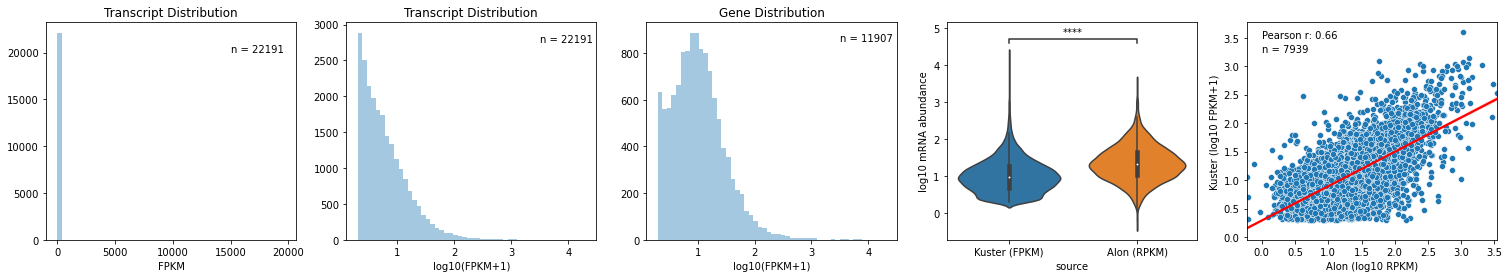

In [15]:
fig, ax = plt.subplots(ncols = 5, figsize = (26, 4))

sns.distplot(transcriptome_og.iloc[:,1:].median(axis = 1), ax = ax[0], kde = False)
ax[0].set(title = 'Transcript Distribution', xlabel = 'FPKM')
ax[0].annotate('n = {}'.format(transcriptome_og.shape[0]), xy = (15000,20000))

sns.distplot(np.log10(transcriptome_og.iloc[:,1:]+1).median(axis = 1), ax = ax[1], kde = False)
ax[1].set(title = 'Transcript Distribution', xlabel = 'log10(FPKM+1)')
ax[1].annotate('n = {}'.format(transcriptome_og.shape[0]), xy = (3.5,2750))


sns.distplot(np.log10(transcriptome+1).median(axis = 1), ax = ax[2], kde = False)
ax[2].set(title = 'Gene Distribution', xlabel = 'log10(FPKM+1)')
ax[2].annotate('n = {}'.format(transcriptome.shape[0]), xy = (3.5,850))

# sns.distplot(np.log10(transcriptome+1).median(axis = 1), kde = False, ax = ax[3])
# sns.distplot(np.log10(df['RNA.RPKM']), kde = False, ax = ax[3])
# ax[3].set(xlabel = 'log10 mRNA abundance')
viz_df = pd.DataFrame(data = {'log10 mRNA abundance': np.log10(transcriptome+1).median(axis = 1).tolist() + df['log10_RNA.RPKM'].tolist(), 
                              'source': ['Kuster (FPKM)']*transcriptome.shape[0] + ['Alon (RPKM)']*df.shape[0]})
sns.violinplot(y = 'log10 mRNA abundance', x = 'source', data = viz_df, ax = ax[3])
tests = asa(ax[3], data=viz_df, y = 'log10 mRNA abundance', x = 'source',
                                   box_pairs=[tuple(viz_df.source.unique())],
                                   test='Mann-Whitney', text_format='star',
                                   loc='inside', verbose=2)


viz_df = pd.DataFrame(index = sorted(set(df.index).intersection(transcriptome.index)))
viz_df['Alon (log10 RPKM)'] = df.loc[viz_df.index, 'log10_RNA.RPKM']
viz_df['Kuster (log10 FPKM+1)'] = np.log10(transcriptome +1).loc[viz_df.index,:].median(axis = 1)
sns.scatterplot(x = 'Alon (log10 RPKM)', y = 'Kuster (log10 FPKM+1)', data = viz_df, ax = ax[4])
sns.regplot(x = 'Alon (log10 RPKM)', y = 'Kuster (log10 FPKM+1)', data = viz_df, ax = ax[4], 
            color = 'red', scatter = False)
ax[4].annotate('Pearson r: {:.2f}'.format(pearsonr(viz_df['Alon (log10 RPKM)'], 
                                                   viz_df['Kuster (log10 FPKM+1)'])[0]), xy = (0, 3.5))
ax[4].annotate('n = {}'.format(viz_df.shape[0]), xy = (0, 3.25))



plt.savefig(local_data_path + 'figures/transcriptome_distributions.pdf', bbox_to_inches = 'tight')
plt.savefig(local_data_path + 'figures/transcriptome_distributions.png', bbox_to_inches = 'tight');